<a href="https://colab.research.google.com/github/antonum/sandbox/blob/pgvector/video_to_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm *.jpg

rm: cannot remove '*.jpg': No such file or directory


In [2]:

!wget https://www.sample-videos.com/video321/mp4/240/big_buck_bunny_240p_30mb.mp4

--2025-03-04 02:49:35--  https://www.sample-videos.com/video321/mp4/240/big_buck_bunny_240p_30mb.mp4
Resolving www.sample-videos.com (www.sample-videos.com)... 103.145.51.95
Connecting to www.sample-videos.com (www.sample-videos.com)|103.145.51.95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31539436 (30M) [video/mp4]
Saving to: ‘big_buck_bunny_240p_30mb.mp4’

big_buck_bunny_240p 100%[===================>]  30.08M  6.59MB/s    in 4.6s    

2025-03-04 02:49:41 (6.59 MB/s) - ‘big_buck_bunny_240p_30mb.mp4’ saved [31539436/31539436]



In [ ]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('big_buck_bunny_240p_30mb.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

# Clear output before saving!!!

In [4]:
import cv2
vidcap = cv2.VideoCapture('big_buck_bunny_240p_30mb.mp4')
success,image = vidcap.read()
count = 0
skip_frames = 50
frame = 0
while success:
  #print (count)
  if count % skip_frames == 0:
    cv2.imwrite("frame%05d.jpg" % frame, image)     # save frame as JPEG file
    success,image = vidcap.read()
    #print('Read a new frame: ',count, success)
    frame += 1
  else:
    success,image = vidcap.read()
  count += 1

In [5]:
# Embeddings using MobileNetV2. Fast, but less precise

import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2 # import MobileNetV2
from tensorflow.keras.preprocessing import image

VECTOR_DIM=1280

# Load pre-trained MobileNetV2 model
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

def generate_embedding(image_path):
  img = image.load_img(image_path, target_size=(224, 224))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = preprocess_input(x)
  embedding = model.predict(x)
  return embedding.flatten()




<ipython-input-5-2a2204055015>:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# ViTModel slower, but delivers better results
from transformers import ViTModel, ViTFeatureExtractor
from PIL import Image as PILImage
import torch

# Load the feature extractor and model
feature_extractor = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224')
model = ViTModel.from_pretrained('google/vit-base-patch16-224')

VECTOR_DIM=768

def generate_embedding(image_path):
  # Preprocess the image
  img = PILImage.open(image_path)
  inputs = feature_extractor(images=img, return_tensors='pt')

  # Extract features
  with torch.no_grad():
      outputs = model(**inputs)
      last_hidden_states = outputs.last_hidden_state
      embedding=last_hidden_states[0, 0, :]
  return embedding

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# length of embedding
#len(embedding)
#embedding

In [8]:
import psycopg2
from google.colab import userdata
#CONNECTION="postgres://tsdbadmin:xxxxxxx.yyyyy.tsdb.cloud.timescale.com:39966/tsdb?sslmode=require"
CONNECTION=userdata.get('TS_CONNECTION')
conn = psycopg2.connect(CONNECTION)
cursor = conn.cursor()

In [9]:

query = """
DROP TABLE IF EXISTS video_embeddings CASCADE;
"""
cursor.execute(query)
conn.commit()

In [10]:
#cursor.execute(query)
conn.commit()

In [11]:
query = f"""
-- create postgres table
CREATE TABLE video_embeddings (
   UUID UUID NOT NULL,
   x FLOAT,
   timestamp TIMESTAMPTZ NOT NULL,
   locationId INT,
   frameId INT,
   h FLOAT,
   eventId INT,
   videoPath TEXT,
   customerId INT,
   w FLOAT,
   receiveTime TIMESTAMPTZ,
   streamId INT,
   y FLOAT,
   vector VECTOR({VECTOR_DIM}), -- 1280 for MobileNetV2; 786 for ViT
   videoName TEXT,
   PRIMARY KEY (UUID, timestamp)
);
"""
cursor.execute(query)
conn.commit()

In [12]:
import uuid
import os
from datetime import datetime
# Construct the SQL query
query = """
              INSERT INTO video_embeddings (UUID, timestamp, vector, frameId, videoName)
              VALUES (%s, %s, %s, %s, %s)
          """
batch_size=10

image_files = [f for f in os.listdir('.') if f.startswith('frame') and f.endswith('.jpg')]


for image_file in image_files:
    embedding = generate_embedding(image_file)
    if embedding is not None:
        #print(f"Embedding for {image_file}: {embedding}")
        print(f"Embedding for {image_file}")
    # Prepare the data for insertion
    current_time = datetime.now()
    unique_uuid = uuid.uuid4()
    frame_id = int(image_file[5:-4])  # Extract frame ID from filename
    # Execute the query
    cursor.execute(query, (str(unique_uuid), current_time, embedding.tolist(), frame_id, "big_buck_bunny"))
    if frame_id % batch_size == 0:
      conn.commit()
conn.commit()


Embedding for frame00034.jpg
Embedding for frame00097.jpg
Embedding for frame00038.jpg
Embedding for frame00078.jpg
Embedding for frame00055.jpg
Embedding for frame00062.jpg
Embedding for frame00032.jpg
Embedding for frame00072.jpg
Embedding for frame00001.jpg
Embedding for frame00106.jpg
Embedding for frame00070.jpg
Embedding for frame00002.jpg
Embedding for frame00010.jpg
Embedding for frame00109.jpg
Embedding for frame00043.jpg
Embedding for frame00024.jpg
Embedding for frame00074.jpg
Embedding for frame00025.jpg
Embedding for frame00047.jpg
Embedding for frame00029.jpg
Embedding for frame00005.jpg
Embedding for frame00013.jpg
Embedding for frame00089.jpg
Embedding for frame00108.jpg
Embedding for frame00085.jpg
Embedding for frame00083.jpg
Embedding for frame00061.jpg
Embedding for frame00004.jpg
Embedding for frame00093.jpg
Embedding for frame00060.jpg
Embedding for frame00053.jpg
Embedding for frame00040.jpg
Embedding for frame00028.jpg
Embedding for frame00027.jpg
Embedding for 

In [13]:
query = """
CREATE INDEX IF NOT EXISTS vector_idx_cosine
ON video_embeddings USING diskann (vector vector_cosine_ops);
"""
cursor.execute(query)
conn.commit()

In [14]:
import pandas as pd
def sql_results_to_df(cursor):
  columns = [desc[0] for desc in cursor.description]
  data = cursor.fetchall()
  df = pd.DataFrame(data, columns=columns)
  return df


In [15]:
# regular SQL query just to check things being inserted
query = """
SELECT timestamp, frameid, vector
FROM video_embeddings
LIMIT 5;
"""
cursor.execute(query)
sql_results_to_df(cursor)

,timestamp,frameid,vector
0,2025-03-04 02:50:32.034151+00:00,34,"[-0.21223496,-1.6482328,-1.4200224,0.2505826,-..."
1,2025-03-04 02:50:32.869501+00:00,97,"[-1.5928875,-1.6494012,-0.7482607,1.2324951,-1..."
2,2025-03-04 02:50:33.617012+00:00,38,"[-1.1456242,-0.08220726,-0.61208236,-0.2411358..."
3,2025-03-04 02:50:34.714318+00:00,78,"[-0.01288928,-0.62707037,-0.67412037,0.3644732..."
4,2025-03-04 02:50:35.688116+00:00,55,"[-0.4489191,-1.0381342,-0.7587099,0.15806077,-..."


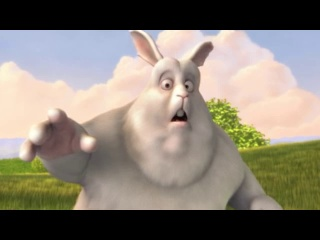

In [16]:
from IPython.display import Image as IPythonImage, display
from PIL import Image as PILImage
from tensorflow.keras.preprocessing import image


#filename='frame00051.jpg' #rodents
filename='frame00045.jpg' #bunny
#filename='frame00053.jpg' #landscape

# vector query against single embedding
embedding = generate_embedding(filename)
display(IPythonImage(filename=filename))
#apple_embedding

frame00045.jpg


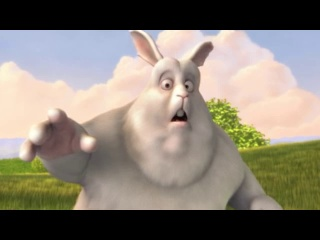

frame00038.jpg


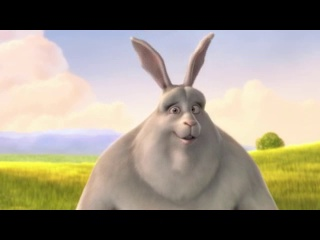

frame00036.jpg


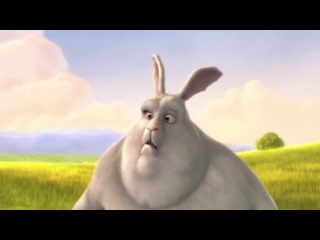

frame00004.jpg


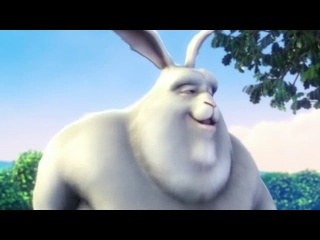

frame00019.jpg


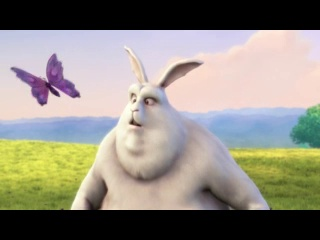

In [17]:
query = """
SELECT timestamp, frameid, vector,
vector <=> %s AS distance
FROM video_embeddings
ORDER BY distance
LIMIT 5;
"""
cursor.execute(query, [str(embedding.tolist())])
df=sql_results_to_df(cursor)

#from IPython.display import Image, display

# Iterate over the 'frameid' column and format it
df['frameid'] = df['frameid'].apply(lambda x: f'frame{x:05d}.jpg')


# Display the images
for filename in df['frameid']:
    print(filename)
    display(IPythonImage(filename=filename))

Now let's analyze both embeddings for entire table

In [18]:
filename1='frame00051.jpg' #rodent
filename2='frame00045.jpg' #bunny
filename3='frame00053.jpg' #landscape

# vector query against single embedding
rodent_embedding = generate_embedding(filename1)
bunny_embedding = generate_embedding(filename2)
landscape_embedding = generate_embedding(filename3)
query = """
SELECT frameid,
1 - (vector <=> %s) AS similarity_rodent,
1 - (vector <=> %s) AS similarity_bunny,
1 - (vector <=> %s) AS similarity_landscape
FROM video_embeddings
ORDER BY frameid
"""
cursor.execute(query, [str(rodent_embedding.tolist()), str(bunny_embedding.tolist()), str(landscape_embedding.tolist())])
df=sql_results_to_df(cursor)
df

,frameid,similarity_rodent,similarity_bunny,similarity_landscape
0,0,0.346852,0.472093,0.413951
1,1,0.263120,0.211619,0.305787
2,2,0.229807,0.614020,0.181903
3,3,0.221148,0.282856,0.180105
4,4,0.235988,0.707208,0.189676
...,...,...,...,...
106,106,0.266084,0.157036,0.056358
107,107,0.232715,0.127559,0.193477
108,108,0.266189,0.404554,0.158682
109,109,0.369678,0.155504,0.188308


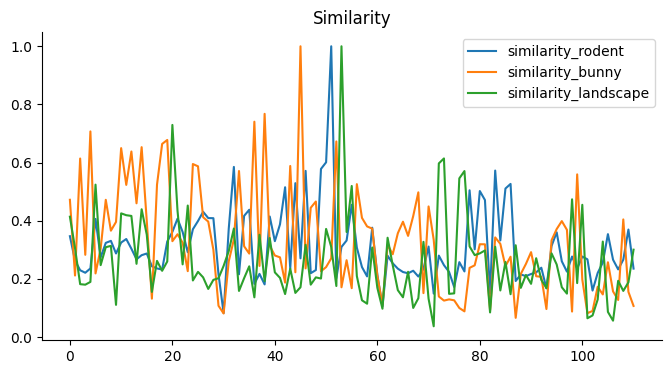

In [19]:
# @title distance_rodent

from matplotlib import pyplot as plt
df[['similarity_rodent', 'similarity_bunny', 'similarity_landscape']].plot(kind='line', figsize=(8, 4), title='Similarity')
plt.gca().spines[['top', 'right']].set_visible(False)